In [ ]:
import pandas as pd

file_path = "AutoEIT Sample Transcriptions for Scoring.xlsx"
# Load the first part
df = pd.read_excel(file_path, sheet_name="38001-1A")

df.head()

,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo (7),Quiero cortarme el pelo,NaN
1,2,El libro está en la mesa (7),El libro está en la mesa,NaN
2,3,El carro lo tiene Pedro (8),El carro lo tiene Pedro,NaN
3,4,El se ducha cada mañana (9),El se ducha cada mañana,NaN
4,5,¿Qué dice usted que va a hacer hoy? (9),Que dices ustedes se que van a hacer hoy?,NaN


In [ ]:
import re
import unicodedata

# ==========================================
# TEXT NORMALIZATION FUNCTIONS
# ==========================================

def remove_accents(text):
    """Removes accent marks so 'películas' becomes 'peliculas' for fair comparison."""
    if pd.isna(text): return ""
    return ''.join(c for c in unicodedata.normalize('NFD', str(text)) if unicodedata.category(c) != 'Mn')

def clean_stimulus(text):
    """Removes syllable counts and normalizes target sentences."""
    if pd.isna(text): return ""
    text = str(text)
    text = re.sub(r'\(\d+\)', '', text)  # Remove syllable counts like (12)
    text = remove_accents(text)          # ACCENT FIX APPLIED
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    return text.strip().lower()

def clean_transcription(text):
    """Removes human rater noise, hesitations, and false starts."""
    if pd.isna(text): return ""
    text = str(text)
    # Ignores hesitations and false starts per Exception rules
    text = re.sub(r'\[pause\]|\[gibberish\]|\[cough\]|xxx|um|uh', '', text, flags=re.IGNORECASE)
    text = remove_accents(text)          # ACCENT FIX APPLIED
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text)     # Remove extra spaces
    return text.strip().lower()

# Apply the cleaning functions
df['Clean_Stimulus'] = df['Stimulus'].apply(clean_stimulus)
df['Clean_Transcription'] = df['Transcription Rater 1'].apply(clean_transcription)

# Verify the cleaning
df[['Clean_Stimulus', 'Clean_Transcription']].head()

,Clean_Stimulus,Clean_Transcription
0,quiero cortarme el pelo,quiero cortarme el pelo
1,el libro esta en la mesa,el libro esta en la mesa
2,el carro lo tiene pedro,el carro lo tiene pedro
3,el se ducha cada manana,el se ducha cada manana
4,que dice usted que va a hacer hoy,que dices ustedes se que van a hacer hoy


In [ ]:
from sentence_transformers import SentenceTransformer, util

# ==========================================
# MEANING-BASED SCORING ENGINE
# ==========================================

print("Loading ML Semantic Model...")
ml_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("Model Loaded!")

# Define Spanish function words to isolate "Content Words" (Idea Units)
FUNCTION_WORDS = {"el", "la", "los", "las", "un", "una", "unos", "unas", "de", "en", "a", "que", "y", "o", "pero", "se", "me", "te", "le", "nos", "les", "con", "por", "para"}

def calculate_score_strict(row):
    stimulus_raw = str(row['Clean_Stimulus']).strip()
    transcription_raw = str(row['Clean_Transcription']).strip()

    stimulus = stimulus_raw.split()
    transcription = transcription_raw.split()

    # TABLE 1: Score 0 Logic
    if not transcription or transcription_raw == 'xxx':
        return 0

    content_words_trans = [w for w in transcription if w not in FUNCTION_WORDS]
    if len(transcription) <= 2 or len(content_words_trans) <= 1:
        return 0

    # TABLE 5: Score 4 Logic
    if stimulus_raw == transcription_raw:
        return 4

    # Calculate Idea Units (Overlap) and Meaning (Semantic Score)
    stim_set = set(stimulus)
    trans_set = set(transcription)

    overlap_ratio = len(stim_set & trans_set) / len(stim_set) if stim_set else 0

    emb_stim = ml_model.encode(stimulus_raw, convert_to_tensor=True)
    emb_trans = ml_model.encode(transcription_raw, convert_to_tensor=True)
    semantic_score = util.cos_sim(emb_stim, emb_trans).item()

    # TABLE 4: Score 3 Logic
    if semantic_score >= 0.88 and overlap_ratio >= 0.70:
        return 3

    # TABLE 3: Score 2 Logic
    if overlap_ratio > 0.50 and semantic_score >= 0.60:
        return 2

    # TABLE 2: Score 1 Logic
    if overlap_ratio <= 0.50 or semantic_score < 0.60:
        return 1

    return 0

# Apply the  scoring to your test dataframe to see if it works
df['Automated_Score'] = df.apply(calculate_score_strict, axis=1)
df[['Clean_Stimulus', 'Clean_Transcription', 'Automated_Score']].head(15)

Loading ML Semantic Model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model Loaded!


,Clean_Stimulus,Clean_Transcription,Automated_Score
0,quiero cortarme el pelo,quiero cortarme el pelo,4
1,el libro esta en la mesa,el libro esta en la mesa,4
2,el carro lo tiene pedro,el carro lo tiene pedro,4
3,el se ducha cada manana,el se ducha cada manana,4
4,que dice usted que va a hacer hoy,que dices ustedes se que van a hacer hoy,2
5,dudo que sepa manejar muy bien,dudo que sepa manajar bien,2
6,las calles de esta ciudad son muy anchas,las calles de esta cuidad son muy anchas,3
7,puede que llueva manana todo el dia,puede que lleva manana todo el dia,2
8,las casas son muy bonitas pero caras,las casas son muy bonitas pero muy cadas,2
9,me gustan las peliculas que acaban bien,me gustan las peliculas que acaban bien,4


In [ ]:
# ==========================================
# EXECUTE, PRINT & EXPORT ALL SHEETS
# ==========================================

def process_all_participants(input_file, output_file):
    print(f"Loading workbook: {input_file}\n")

    # Read all sheets into a dictionary of DataFrames
    all_sheets = pd.read_excel(input_file, sheet_name=None)

    # Create an Excel writer to save multiple tabs into one output file
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:

        for sheet_name, df_sheet in all_sheets.items():
            # Skip the 'Info' tab or any tab without the correct columns
            if 'Stimulus' not in df_sheet.columns or 'Transcription Rater 1' not in df_sheet.columns:
                print(f"Skipping sheet: '{sheet_name}' (No transcript data found)\n")
                continue

            print(f"Scoring participant: '{sheet_name}'...")

            # Apply cleaning
            df_sheet['Clean_Stimulus'] = df_sheet['Stimulus'].apply(clean_stimulus)
            df_sheet['Clean_Transcription'] = df_sheet['Transcription Rater 1'].apply(clean_transcription)

            # Apply scoring
            df_sheet['Automated_Score'] = df_sheet.apply(calculate_score_strict, axis=1)

            # Format output
            final_output = df_sheet[['Sentence', 'Stimulus', 'Transcription Rater 1', 'Automated_Score']]

            # Save this participant's data to a new tab in the final Excel file
            final_output.to_excel(writer, sheet_name=sheet_name, index=False)

            # --- NEW: PRINT THE RESULTS FOR THIS TAB ---
            print(f"\n{'='*70}")
            print(f" PREVIEW FOR SHEET: {sheet_name}")
            print(f"{'='*70}")
            # Printing the first 15 rows of each sheet for a clean visual check
            print(final_output.head(15).to_string(index=False))
            print("\n")

    print(f" Success! All sheets scored and exported to: {output_file}")

# --- RUN THE CODE ---

INPUT_FILENAME = "AutoEIT Sample Transcriptions for Scoring.xlsx"
OUTPUT_FILENAME = "Final_Master_Scores_AutoEIT.xlsx"

process_all_participants(INPUT_FILENAME, OUTPUT_FILENAME)

Loading workbook: AutoEIT Sample Transcriptions for Scoring.xlsx

Skipping sheet: 'Info' (No transcript data found)

Scoring participant: '38001-1A'...

 PREVIEW FOR SHEET: 38001-1A
 Sentence                                            Stimulus                           Transcription Rater 1  Automated_Score
        1                         Quiero cortarme el pelo (7)                         Quiero cortarme el pelo                4
        2                        El libro está en la mesa (7)                        El libro está en la mesa                4
        3                         El carro lo tiene Pedro (8)                         El carro lo tiene Pedro                4
        4                         El se ducha cada mañana (9)                         El se ducha cada mañana                4
        5             ¿Qué dice usted que va a hacer hoy? (9)       Que dices ustedes se que van a hacer hoy?                2
        6                 Dudo que sepa manejar muy bien

Generating performance visualization from: Final_Master_Scores_AutoEIT.xlsx...


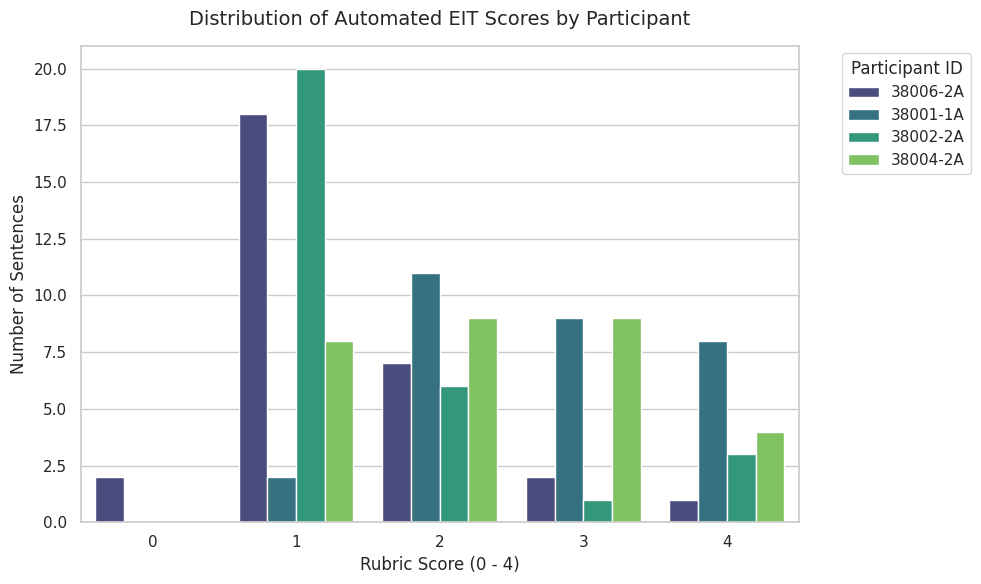

 Visualization saved as: EIT_Score_Distribution.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# BLOCK 4: DATA VISUALIZATION
# ==========================================

def visualize_results(master_excel_file):
    print(f"Generating performance visualization from: {master_excel_file}...")

    # Read all sheets from the master file we just created
    all_data = pd.read_excel(master_excel_file, sheet_name=None)

    # Combine them into one dataframe for plotting
    combined_df = pd.DataFrame()
    for sheet_name, df_sheet in all_data.items():
        df_sheet['Participant'] = sheet_name
        combined_df = pd.concat([combined_df, df_sheet])

    # Set the visual style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # Create a grouped bar chart
    ax = sns.countplot(
        data=combined_df,
        x='Automated_Score',
        hue='Participant',
        palette='viridis'
    )

    # Add labels and titles
    plt.title('Distribution of Automated EIT Scores by Participant', fontsize=14, pad=15)
    plt.xlabel('Rubric Score (0 - 4)', fontsize=12)
    plt.ylabel('Number of Sentences', fontsize=12)
    plt.legend(title='Participant ID', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Save the chart as a image
    plt.tight_layout()
    image_filename = 'EIT_Score_Distribution.png'
    plt.savefig(image_filename, dpi=300)


    plt.show()
    print(f" Visualization saved as: {image_filename}")

# --- RUN THE VISUALIZER ---
MASTER_FILE = "Final_Master_Scores_AutoEIT.xlsx"
visualize_results(MASTER_FILE)